In [1]:
from src.evaluate import load_checkpoint, predict_in_batches
from src.model import build_model
from src.evaluate import load_config, get_model_config
import torch
import numpy as np
import json
from src.preprocessing import psln_inverse, PSLNStats

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullLocator

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = load_config("configs/main_experiment.yaml")
model_config_PINGP = get_model_config(config, "main")
model_config_SIREN = get_model_config(config, "siren")

In [3]:
data_input = np.load('examples/sample_input.npy')
data_output = np.load('examples/sample_output.npy')

In [4]:

with open("examples/preprocessing_stats.json", "r", encoding="utf-8") as f:
    preprocessing_stats = json.load(f)


In [5]:
model_PINGP = build_model(model_config_PINGP)
model_PINGP = model_PINGP.to(device)
model_PINGP = load_checkpoint(
    model=model_PINGP,
    checkpoint_path="checkpoints/PINGP_2_final.pt",
    device=device,
)

model_SIREN = build_model(model_config_SIREN)
model_SIREN = model_SIREN.to(device)
model_SIREN = load_checkpoint(
    model=model_SIREN,
    checkpoint_path="checkpoints/SIREN_2_final.pt",
    device=device,
)

In [6]:
def inverse_PSLN(y_data, preprocessing_stats):
    for i in range(3):
        norm_const = PSLNStats(scale = preprocessing_stats['output_stats']['scale'][i],
                                     min = preprocessing_stats['output_stats']['min'][i],
                                     max = preprocessing_stats['output_stats']['max'][i],
                                     percentile = preprocessing_stats['output_stats']['percentile'],
                                     scale_constant = preprocessing_stats['output_stats']['scale_constant'])
        y_data[:, i] = psln_inverse(y_data[:, i], norm_const)

    return y_data
    

In [7]:


def visualize_compact_log(
    r, z,
    array,
    quantity_idx=2,
    color_range=None,    # (vmin, vmax) or None
    show_colorbar=True,   # True / False
    tick=False,
):

    x, y = r, z
    q = array[:, quantity_idx].copy()

    if quantity_idx == 0:
        quantity_name = "Velocity (cm/s)"
        default_vmin = 1e4
    elif quantity_idx == 1:
        quantity_name = "Pressure (Pa)"
        default_vmin = 1e3
    elif quantity_idx == 2:
        quantity_name = "Density (g/cm³)"
        default_vmin = 1e-7
    else:
        raise ValueError("quantity_idx must be 0, 1, or 2")


    q_pos = q[q > 0]
    vmin = default_vmin if len(q_pos) == 0 else q_pos.min()
    q[q <= 0] = vmin


    if color_range is not None:
        vmin, vmax = color_range
    else:
        vmin = default_vmin
        vmax = q.max()


    fig = plt.figure(figsize=(5, 2))
    ax = fig.add_axes([0.15, 0.2, 0.55, 0.7])

    scatter = ax.scatter(
        x, y, c=q, s=0.5, cmap="jet", alpha=0.6,
        norm=colors.LogNorm(vmin=vmin, vmax=vmax),
        rasterized=True
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)


    if tick:
        ticks = np.linspace(0, 1, 5)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        
        ax.set_xticklabels([fr"{int(v * 2000)} $\mu$m" if i == len(ticks)-1 else f"{int(v * 2000)}" for i, v in enumerate(ticks)], fontsize=10)
        ax.set_yticklabels([fr"{int(v * 700)} $\mu$m" if i == len(ticks)-1 else f"{int(v * 700)}" for i, v in enumerate(ticks)], fontsize=10)
    else:
        ax.set_xticks([])
        ax.set_yticks([])


    if show_colorbar:
        cbar = plt.colorbar(scatter, ax=ax, pad=0.05)
        cbar.locator = LogLocator(base=10.0)
        cbar.formatter = LogFormatterMathtext(base=10.0)
        cbar.ax.yaxis.set_minor_locator(NullLocator())
        
        cbar.set_label(quantity_name, fontsize=8)
        cbar.ax.tick_params(labelsize=7, which="major")

    plt.show()
    return vmin, vmax

In [8]:
t = 8
J = 1.3
tau = 10

t_norm = t / 100
J_norm = np.log1p(J) / 10
tau_norm = tau / 100

mask = (data_input[:, 2] == t_norm) & \
       (data_input[:, 3] == J_norm) & \
       (data_input[:, 4] == tau_norm)

filtered_data = data_input[mask]

final_idx = np.where(mask)[0]
infer_input = data_input[final_idx]
infer_gt = data_output[final_idx]
r, z = infer_input[:, 0], infer_input[:, 1]

prediction_PINGP = model_PINGP(torch.tensor(infer_input).cuda())
prediction_PINGP = prediction_PINGP.detach().cpu().float().numpy()
prediction_SIREN = model_SIREN(torch.tensor(infer_input).cuda())
prediction_SIREN = prediction_SIREN.detach().cpu().float().numpy()

In [9]:
inv_gt = inverse_PSLN(infer_gt.copy(), preprocessing_stats)
inv_pred_SIREN = inverse_PSLN(prediction_SIREN.copy(), preprocessing_stats)
inv_pred_PINGP = inverse_PSLN(prediction_PINGP.copy(), preprocessing_stats)

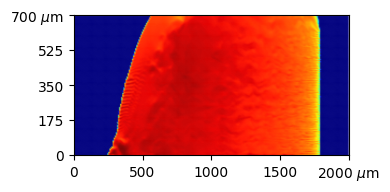

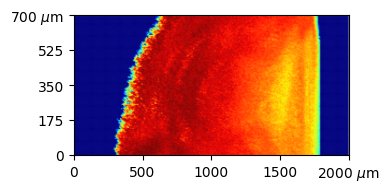

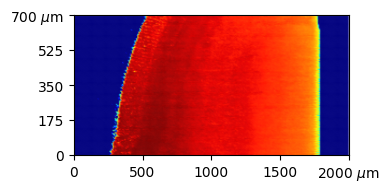

In [10]:
quantity_idx = 0
c_min, c_max = visualize_compact_log(r, z, inv_gt, quantity_idx = quantity_idx, show_colorbar = False, tick=True)
c_min, c_max = visualize_compact_log(r, z, inv_pred_SIREN, quantity_idx = quantity_idx, show_colorbar = False, tick=True, color_range = (c_min, c_max))
c_min, c_max = visualize_compact_log(r, z, inv_pred_PINGP, quantity_idx = quantity_idx, show_colorbar = False, tick=True, color_range = (c_min, c_max))